# Partial-Conversation Oracle EDA

**Question.** PTO and GRPO_Exp3 use Q1+Q2 oracle scores on *partial* conversations as their training reward — slices as short as 2 turns. The thesis evaluates models on *final* (full) conversations. If those two signals disagree, the training oracle is not a good proxy for what we measure.

**Approach.** For two models — `Base` and the best `L5_Q1Q2_V*` iteration — slice each of the 96 conversations at every other patient turn, score every cut with Q1+Q2 (gpt-4o-mini, t=0.1), then compare against the pre-existing final-conversation Q1+Q2 scores. All cuts are cached on disk, so re-runs cost zero API calls.

## TL;DR

1. **The partial reward is least faithful where it matters most.** At `n_turns=2` — a real PTO/GRPO_Exp3 training cut — pairwise rank agreement vs. the full-conv eval is only **0.66 (Base) / 0.73 (L5_V10)**, barely above chance (0.5).
2. **Oracle noise floor.** Same final transcript scored twice differs by mean |Δ| ≈ **0.07 (L5_V10) / 0.10 (Base)** — anything below that is jitter.
3. **Per-cut |Δ| confirms it from the magnitude side.** Mean `|partial − final|` decays monotonically toward the noise floor as cuts grow; short cuts sit well above it, so the disagreement isn't a sign flip on near-tied scores.
4. **Agreement grows monotonically with cut length.** Clears 0.8 around `n_turns ≈ 10`, clears 0.9 around `n_turns ≈ 30`, reaches >0.95 at full length.
5. **Implication.** A meaningful share of PTO/GRPO_Exp3 training signal points in directions the eval rubric does not endorse. This is structural (short cuts can't see follow-through), not noise.


## 1. Setup

One import + config cell. Knobs `MIN_TURNS=2` and `SAMPLE_EVERY_N_PATIENT_TURNS=2` match PTO/GRPO_Exp3 slicing; changing them invalidates the cache.


In [1]:
import asyncio
import os
from itertools import combinations
from typing import List

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from IPython.display import display
from scipy.stats import kendalltau, pearsonr, spearmanr

from lib import (
    WORKSPACE_ROOT, EDAConfig, eval_scores_root_for_method, get_model_eval_layout,
    EXPERIMENTS, resolve_paths, get_model_names,
    load_data, combine_data, add_model_metadata_columns,
    reconstruct_conversation_text,
    load_all_eval_results, merge_q1_q2_results,
    set_plot_style,
)
from lib import eval as oracle_eval

assert oracle_eval.EVAL_CODE_AVAILABLE, \
    "questionnaires module not on sys.path — verify Exp3_PTO_GRPO/code/ is reachable."
set_plot_style()

MIN_TURNS = 2
SAMPLE_EVERY_N_PATIENT_TURNS = 1
CONCURRENCY = 32
# Base + L5_Q1Q2_V* are Exp2-provenance models, so their partial-cut cache lives
# under the Exp2 eval_scores root, beside their full-conv scores. (The partial
# cache is a Q1+Q2 diagnostic keyed by model only — not part of the labelled
# metric=/oracle= eval tree.)
CACHE_DIR = os.path.join(eval_scores_root_for_method("DPO"), "partial_q1q2")
os.makedirs(CACHE_DIR, exist_ok=True)

# Regular sampling cadence implied by the knobs above: cuts at 2, 6, 10, ..., 50 turns.
# Off-cadence lengths (8, 12, 16, ...) only appear when a conversation ended at exactly
# that length, so those bins are sparse (1-8 patients) and noisy. Filter on this when
# plotting / tabulating per-bin statistics.
REGULAR_N_TURNS = set(range(MIN_TURNS, 51, 2 * SAMPLE_EVERY_N_PATIENT_TURNS))

config = EDAConfig(async_concurrency=CONCURRENCY)
print(f"Eval model / temp : {config.eval_model} / {config.eval_temp}")
print(f"Cache dir         : {CACHE_DIR}")
print(f"Regular cadence   : {sorted(REGULAR_N_TURNS)}")

Eval model / temp : gpt-4o-mini-2024-07-18 / 0.1
Cache dir         : c:\Users\baruc\Desktop\Projects\Thesis_PTO_GRPO\Exp3_PTO_GRPO\data\pto_Exp2\eval_scores\partial_q1q2
Regular cadence   : [2, 4, 6, 8, 10, 12, 14, 16, 18, 20, 22, 24, 26, 28, 30, 32, 34, 36, 38, 40, 42, 44, 46, 48, 50]


## 2. Pick best L5 iteration & load data

`Best L5` = highest mean `Q1Q2_Mean` across the 96 patients on the existing final-conversation eval. Top-3 shown for context; full L5 ranking lives in `Conv_EDA.ipynb`.


In [2]:
# ── Pick best L5_Q1Q2 iteration by mean final Q1+Q2 ──
_l5_models = [e.model_name for e in EXPERIMENTS if e.model_name.startswith("L5_Q1Q2_V")]
_model_layout = get_model_eval_layout()          # model -> {'root', 'oracle'}
_q1q2_dirs = {"Q1": "Q1", "Q2": "Q2"}            # only Q1+Q2 needed here
_l5_eval = load_all_eval_results(_model_layout, _l5_models, questionnaire_dirs=_q1q2_dirs)
_l5_q1q2 = merge_q1_q2_results(_l5_eval.get("Q1"), _l5_eval.get("Q2"))
_per_model = (
    _l5_q1q2.groupby("Model", observed=True)["Q1Q2_Mean"]
    .agg(["mean", "std", "count"])
    .sort_values("mean", ascending=False)
)
BEST_L5 = _per_model.index[0]
MODELS = ["Base", BEST_L5]
print(f"Selected: {MODELS}\n")
display(_per_model.head(3).style
        .format({"mean": "{:.3f}", "std": "{:.3f}", "count": "{:.0f}"})
        .set_caption("L5_Q1Q2 — top 3 iterations by mean final Q1+Q2"))

# ── Load conversations + pre-existing final-conv eval scores ──
_selected_exps = [e for e in EXPERIMENTS if e.model_name in MODELS]
conversations = combine_data(load_data(resolve_paths(_selected_exps)),
                             get_model_names(_selected_exps))
conversations["id"] = conversations["id"].astype(int)
conversations = add_model_metadata_columns(conversations)

final_eval = load_all_eval_results(_model_layout, MODELS, questionnaire_dirs=_q1q2_dirs)
final_q1q2 = (
    merge_q1_q2_results(final_eval.get("Q1"), final_eval.get("Q2"))
    [["Model", "patient_id", "Q1_Mean", "Q2_Mean", "Q1Q2_Mean"]]
    .rename(columns={"patient_id": "id",
                     "Q1_Mean": "final_Q1_Mean",
                     "Q2_Mean": "final_Q2_Mean",
                     "Q1Q2_Mean": "final_Q1Q2_Mean"})
)
print(f"\n{len(conversations)} conversations | {len(final_q1q2)} final-eval rows")
display(conversations.groupby("Model", observed=True).agg(
    n_conv=("id", "count"),
    mean_len=("conversation_length", "mean"),
    min_len=("conversation_length", "min"),
    max_len=("conversation_length", "max"),
))

Selected: ['Base', 'L5_Q1Q2_V10']



,mean,std,count
Model,,,
L5_Q1Q2_V10,2.968,1.228,96
L5_Q1Q2_V8,2.963,1.188,96
L5_Q1Q2_V9,2.931,1.212,96



192 conversations | 192 final-eval rows


,n_conv,mean_len,min_len,max_len
Model,,,,
Base,96,31.416667,3,50
L5_Q1Q2_V10,96,29.552083,7,50


## 3. Build sub-conversation cuts, score them, aggregate

Each cut is one Q1 call + one Q2 call (gpt-4o-mini, t=0.1) saved to `partial_q1q2/{Model}/{id}_t{n_turns}.csv`. Re-runs skip cached cuts → typically zero API calls.


In [3]:
def build_cuts(utterances: List[str], min_turns: int, sample_every: int) -> List[dict]:
    n = len(utterances)
    patient_idxs = [i for i in range(1, n, 2)]
    valid = [i for i in patient_idxs if (i + 1) >= min_turns]
    if not valid:
        return []
    chosen = valid[::sample_every]
    if chosen[-1] != valid[-1]:
        chosen.append(valid[-1])
    return [{"n_turns": end + 1,
             "is_final": (end == valid[-1]),
             "prefix": list(utterances[: end + 1])} for end in chosen]


cut_rows = []
for _, row in conversations.iterrows():
    for c in build_cuts(row["conversation"], MIN_TURNS, SAMPLE_EVERY_N_PATIENT_TURNS):
        cut_rows.append({"Model": row["Model"], "id": int(row["id"]), **c})
cuts_df = pd.DataFrame(cut_rows)

# Sanity: every cut ends on a patient turn; is_final cut reconstructs the full transcript.
for _model in MODELS:
    for _id in cuts_df["id"].drop_duplicates().head(3):
        _full = conversations[(conversations["Model"] == _model) &
                              (conversations["id"] == _id)].iloc[0]["conversation"]
        _sub = cuts_df[(cuts_df["Model"] == _model) & (cuts_df["id"] == _id)]
        for _, _r in _sub.iterrows():
            assert (_r["n_turns"] - 1) % 2 == 1
        _f = _sub[_sub["is_final"]].iloc[0]
        assert reconstruct_conversation_text(_f["prefix"]) == \
               reconstruct_conversation_text(_full[: _f["n_turns"]])

print(f"{len(cuts_df):,} cuts across {cuts_df[['Model','id']].drop_duplicates().shape[0]} conversations  (sanity ✓)")
display(cuts_df.groupby("Model", observed=True).agg(
    n_cuts=("n_turns", "count"),
    cuts_per_conv=("id", lambda s: round(len(s) / s.nunique(), 2)),
    min_len=("n_turns", "min"), max_len=("n_turns", "max"),
))


2,900 cuts across 192 conversations  (sanity ✓)


,n_cuts,cuts_per_conv,min_len,max_len
Model,,,,
Base,1493,15.55,2,50
L5_Q1Q2_V10,1407,14.66,2,50


In [4]:
def _cache_path(model: str, id_: int, n_turns: int) -> str:
    mdir = os.path.join(CACHE_DIR, model)
    os.makedirs(mdir, exist_ok=True)
    return os.path.join(mdir, f"{id_}_t{n_turns}.csv")


_to_score = [r for _, r in cuts_df.iterrows()
             if not os.path.exists(_cache_path(r["Model"], int(r["id"]), int(r["n_turns"])))]
print(f"{len(_to_score)} of {len(cuts_df)} cuts need scoring")

if _to_score:
    from openai import AsyncOpenAI
    from questionnaires import QuestionnaireID

    with open(os.path.join(WORKSPACE_ROOT, "openai_key.txt")) as fh:
        client = AsyncOpenAI(api_key=fh.read().strip())

    _sem = asyncio.Semaphore(CONCURRENCY)
    _stats = {"completed": 0, "errors": 0}
    _lock = asyncio.Lock()

    async def _score_one(cut):
        fp = _cache_path(cut["Model"], int(cut["id"]), int(cut["n_turns"]))
        async with _sem:
            try:
                r_q1 = await oracle_eval.evaluate_conversation(
                    client, conversation=cut["prefix"], questionnaire_id=QuestionnaireID.Q1)
                r_q2 = await oracle_eval.evaluate_conversation(
                    client, conversation=cut["prefix"], questionnaire_id=QuestionnaireID.Q2)
                if r_q1 is None or r_q2 is None or r_q1.isnull().values.any() or r_q2.isnull().values.any():
                    async with _lock:
                        _stats["errors"] += 1
                    return
                row = pd.concat([r_q1.reset_index(drop=True), r_q2.reset_index(drop=True)], axis=1)
                row["Q1Q2_Mean"] = (row["Q1_Mean"] + row["Q2_Mean"]) / 2.0
                row.to_csv(fp, index=False)
                async with _lock:
                    _stats["completed"] += 1
            except Exception as e:
                print(f"Error {cut['Model']}/{cut['id']}/t{cut['n_turns']}: {e}")
                async with _lock:
                    _stats["errors"] += 1

    await asyncio.gather(*[asyncio.create_task(_score_one(c)) for c in _to_score])
    print(_stats)
else:
    print("All cuts already cached — skipping API calls.")


0 of 2900 cuts need scoring
All cuts already cached — skipping API calls.


In [5]:
# Aggregate all partial scores into one tidy DataFrame, joined with final-conv scores.
_rows = []
for _, c in cuts_df.iterrows():
    fp = _cache_path(c["Model"], int(c["id"]), int(c["n_turns"]))
    if not os.path.exists(fp):
        continue
    r = pd.read_csv(fp).iloc[0].to_dict()
    r.update({"Model": c["Model"], "id": int(c["id"]),
              "n_turns": int(c["n_turns"]), "is_final": bool(c["is_final"])})
    _rows.append(r)
partial_df = pd.DataFrame(_rows).merge(final_q1q2, on=["Model", "id"], how="left")
partial_df["on_cadence"] = partial_df["n_turns"].isin(REGULAR_N_TURNS)
print(f"{len(partial_df):,} partial-score rows  "
      f"({partial_df['on_cadence'].sum():,} on regular cadence, "
      f"{(~partial_df['on_cadence']).sum():,} off-cadence early-termination cuts)")

# ── Synthesize a "Combined" pooled view ────────────────────────────────
# No new API calls — same cached cuts, relabeled and stacked. Patient ids are
# shared across the two real models (same 96 permutations), so pairwise
# analysis on Combined treats (id, Base) and (id, L5_V10) as separate
# observations — which is what we want for a pooled rank-agreement readout.
_combined = partial_df.copy()
_combined["Model"] = "Combined"
partial_df = pd.concat([partial_df, _combined], ignore_index=True)
MODELS = MODELS + ["Combined"]
print(f"Added Combined view: +{len(_combined):,} pooled rows  →  MODELS = {MODELS}")


2,900 partial-score rows  (2,900 on regular cadence, 0 off-cadence early-termination cuts)
Added Combined view: +2,900 pooled rows  →  MODELS = ['Base', 'L5_Q1Q2_V10', 'Combined']


## 4. Result A — Pairwise rank agreement (headline)

For each cut length `K`, count the fraction of patient pairs `(i, j)` where `sign(partial_K_i − partial_K_j) == sign(final_i − final_j)`.

- Pairs with tied final scores excluded (no ground-truth direction).
- Pairs where partials tie but finals don't contribute 0.5 (Kendall τ-b convention).
- **1.0 = perfect ranking consistency; 0.5 = chance.**

This is the right readout for the proxy question — PTO/GRPO_Exp3's loss cares about which candidate scores higher, not the absolute gap.

**What to look for:** at which cut length each model's curve clears 0.8 (usable) and 0.9 (strong). Filter: regular-cadence cuts with ≥ 20 patients per bin.


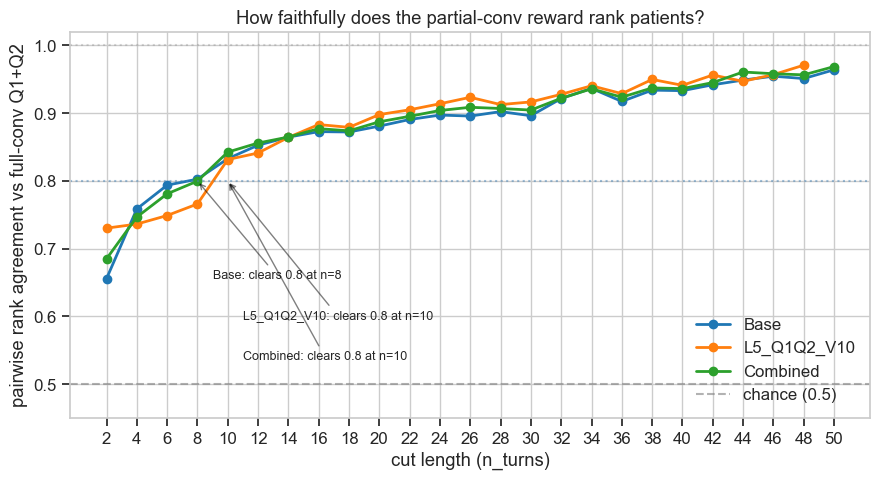

In [13]:
AGREEMENT_THRESHOLD = 0.8   # rank-agreement bar to flag ("faithful enough"); change to taste


def pairwise_agreement(partial: np.ndarray, final: np.ndarray) -> dict:
    n = len(partial)
    if n < 2:
        return {"n_pairs": 0, "agree_rate": np.nan, "kendall_tau": np.nan}
    agree, used = 0.0, 0
    for i, j in combinations(range(n), 2):
        df_full = final[i] - final[j]
        if df_full == 0:
            continue
        used += 1
        df_part = partial[i] - partial[j]
        if df_part == 0:
            agree += 0.5
        elif np.sign(df_part) == np.sign(df_full):
            agree += 1.0
    if used == 0:
        return {"n_pairs": 0, "agree_rate": np.nan, "kendall_tau": np.nan}
    tau, _ = kendalltau(partial, final)
    return {"n_pairs": used, "agree_rate": agree / used, "kendall_tau": tau}


_rows = []
for model in MODELS:
    for n_turns, grp in partial_df[partial_df["Model"] == model].groupby("n_turns"):
        g = grp.dropna(subset=["Q1Q2_Mean", "final_Q1Q2_Mean"])
        if len(g) < 2:
            continue
        _rows.append({"Model": model, "n_turns": int(n_turns), "n_patients": len(g),
                      **pairwise_agreement(g["Q1Q2_Mean"].to_numpy(),
                                           g["final_Q1Q2_Mean"].to_numpy())})
agree_df = pd.DataFrame(_rows)
_keep = agree_df[agree_df["n_turns"].isin(REGULAR_N_TURNS) & (agree_df["n_patients"] >= 20)]

# display(
#     _keep.pivot(index="n_turns", columns="Model",
#                 values=["agree_rate", "kendall_tau", "n_patients"])
#     .style
#     .format("{:.3f}", subset=pd.IndexSlice[:, "agree_rate"])
#     .format("{:.3f}", subset=pd.IndexSlice[:, "kendall_tau"])
#     .format("{:.0f}", subset=pd.IndexSlice[:, "n_patients"])
#     .set_caption("Pairwise rank agreement & Kendall τ — partial-cut vs full-conv Q1+Q2")
# )

fig, ax = plt.subplots(figsize=(9, 5))
for model in MODELS:
    sub = _keep[_keep["Model"] == model].sort_values("n_turns")
    ax.plot(sub["n_turns"], sub["agree_rate"], marker="o", linewidth=2, label=model)
    _cross = sub[sub["agree_rate"] >= AGREEMENT_THRESHOLD]
    if len(_cross):
        _k = int(_cross["n_turns"].iloc[0])
        # park the label below the threshold line and cascade per model, so the
        # arrow rises from below into the crossing point and never crosses the curves
        _y_off = AGREEMENT_THRESHOLD - 0.14 - 0.06 * MODELS.index(model)
        ax.annotate(f"{model}: clears {AGREEMENT_THRESHOLD:g} at n={_k}",
                    xy=(_k, AGREEMENT_THRESHOLD), xytext=(_k + 1, _y_off),
                    fontsize=9, ha="left", va="center",
                    arrowprops=dict(arrowstyle="->", alpha=0.5))
ax.axhline(0.5, ls="--", color="gray", alpha=0.6, label="chance (0.5)")
ax.axhline(AGREEMENT_THRESHOLD, ls=":", color="steelblue", alpha=0.5)
ax.axhline(1.0, ls=":", color="gray", alpha=0.3)
ax.set_xlabel("cut length (n_turns)")
ax.set_ylabel("pairwise rank agreement vs full-conv Q1+Q2")
ax.set_ylim(0.45, 1.02)
ax.set_xticks(sorted(REGULAR_N_TURNS))
ax.set_title("How faithfully does the partial-conv reward rank patients?")
ax.legend(loc="lower right")
plt.tight_layout()
plt.show()

## 5. Result B — Oracle noise floor

Same final transcript, scored twice (once in the original eval, once here for the `is_final` cut). Mean |Δ| is the lower bound on any partial-vs-final discrepancy — anything below it is just oracle jitter, and §6 / §7 use this as a reference.


In [7]:
_final_rows = partial_df[partial_df["is_final"]].copy()
_final_rows["abs_diff"] = (_final_rows["Q1Q2_Mean"] - _final_rows["final_Q1Q2_Mean"]).abs()
display(
    _final_rows.groupby("Model", observed=True)["abs_diff"]
    .agg(["mean", "std", "max", "count"])
    .rename(columns={"mean": "mean_abs_diff"})
    .style.format("{:.3f}", subset=["mean_abs_diff", "std", "max"])
    .format("{:.0f}", subset=["count"])
    .set_caption("|partial(final-cut) Q1+Q2 − stored final Q1+Q2| — same transcript, scored twice")
)


,mean_abs_diff,std,max,count
Model,,,,
Base,0.102,0.140,0.547,96
Combined,0.084,0.122,0.547,192
L5_Q1Q2_V10,0.066,0.100,0.441,96


## 6. Result C — Per-cut absolute error by cut length

For each (patient × cut), compute `|partial Q1+Q2 − final Q1+Q2|` and aggregate by `n_turns`. Sits between §4 (per-pair direction) and §5 (per-transcript jitter): says *by how much* the partial disagrees with the final on the same conversation.

**What to look for:** how fast the curve decays toward the §5 noise floor (drawn as a dashed reference per model). By construction the `n_turns = full conv length` end should sit on the floor; everything above it is structural disagreement.


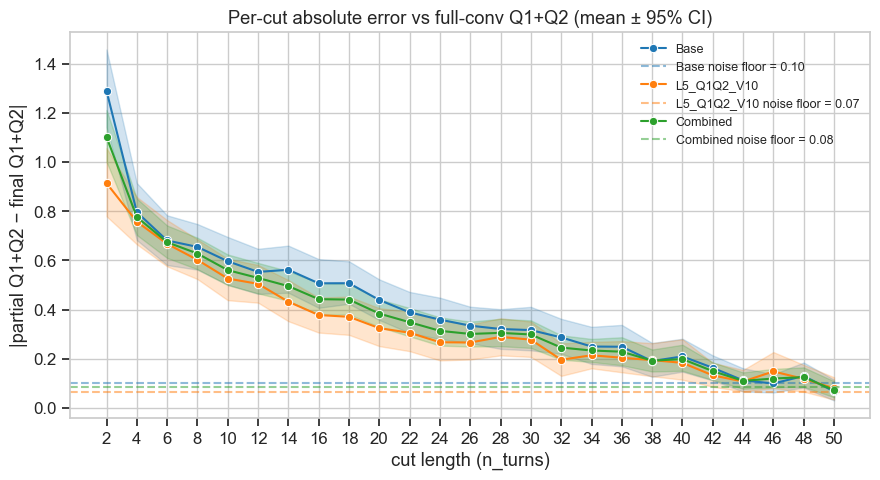

In [14]:
_ad = partial_df.copy()
_ad["abs_diff"] = (_ad["Q1Q2_Mean"] - _ad["final_Q1Q2_Mean"]).abs()
_ad = _ad[_ad["on_cadence"]].dropna(subset=["abs_diff"])

# Per-model noise floor for the reference line (mean |Δ| on is_final cuts).
_noise = (
    partial_df[partial_df["is_final"]]
    .assign(abs_diff=lambda d: (d["Q1Q2_Mean"] - d["final_Q1Q2_Mean"]).abs())
    .groupby("Model", observed=True)["abs_diff"].mean().to_dict()
)

# ── Summary table: mean / median / count per cut length ──
_summary = (
    _ad.groupby(["Model", "n_turns"], observed=True)["abs_diff"]
    .agg(["mean", "median", "count"])
    .reset_index()
)
_summary = _summary[_summary["count"] >= 20]
# display(
#     _summary.pivot(index="n_turns", columns="Model",
#                    values=["mean", "median", "count"])
#     .style
#     .format("{:.3f}", subset=pd.IndexSlice[:, "mean"])
#     .format("{:.3f}", subset=pd.IndexSlice[:, "median"])
#     .format("{:.0f}", subset=pd.IndexSlice[:, "count"])
#     .set_caption("|partial − final| Q1+Q2 by cut length (regular cadence, ≥20 patients)")
# )

# ── Plot: mean |Δ| ± 95% CI per cut length, per model + per-patient scatter ──
fig, ax = plt.subplots(figsize=(9, 5))
for model in MODELS:
    sub = _ad[_ad["Model"] == model]
    sns.lineplot(data=sub, x="n_turns", y="abs_diff",
                 errorbar=("ci", 95), marker="o", ax=ax, label=model)
    ax.axhline(_noise[model], ls="--", alpha=0.5,
               color=ax.lines[-1].get_color(),
               label=f"{model} noise floor = {_noise[model]:.2f}")
ax.set_xlabel("cut length (n_turns)")
ax.set_ylabel("|partial Q1+Q2 − final Q1+Q2|")
ax.set_xticks(sorted(REGULAR_N_TURNS))
ax.set_title("Per-cut absolute error vs full-conv Q1+Q2 (mean ± 95% CI)")
ax.legend(loc="upper right", fontsize=9)
plt.tight_layout()
plt.show()


## 7. Result D — Score trajectory along the conversation

Mean Q1+Q2 across 96 patients at each regular-cadence cut length, with a 95% CI band. Dashed line = stored final Q1+Q2 mean (the limit each curve is converging to).

**What to look for:** how quickly each model's partial score *converges* to its own final score, and whether one model "looks better early" relative to where it ends up.


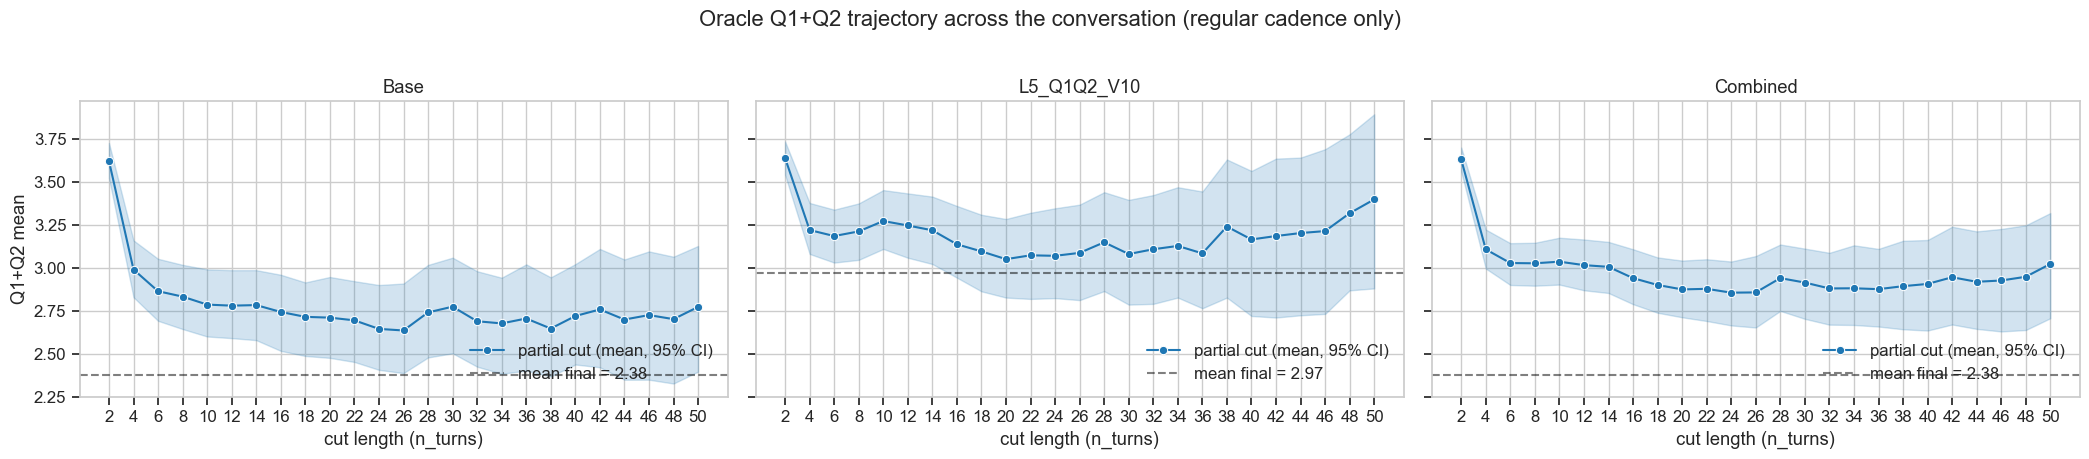

In [9]:
_traj = partial_df[partial_df["on_cadence"]]
fig, axes = plt.subplots(1, len(MODELS), figsize=(7 * len(MODELS), 4.5), sharey=True)
if len(MODELS) == 1:
    axes = [axes]
for ax, model in zip(axes, MODELS):
    sub = _traj[_traj["Model"] == model]
    sns.lineplot(data=sub, x="n_turns", y="Q1Q2_Mean",
                 errorbar=("ci", 95), marker="o", ax=ax, label="partial cut (mean, 95% CI)")
    _final_mean = sub.drop_duplicates("id")["final_Q1Q2_Mean"].mean()
    ax.axhline(_final_mean, ls="--", color="k", alpha=0.5,
               label=f"mean final = {_final_mean:.2f}")
    ax.set_title(model)
    ax.set_xlabel("cut length (n_turns)")
    ax.set_ylabel("Q1+Q2 mean")
    ax.set_xticks(sorted(REGULAR_N_TURNS))
    ax.tick_params(axis="x", rotation=0)
    ax.legend(loc="lower right")
plt.suptitle("Oracle Q1+Q2 trajectory across the conversation (regular cadence only)", y=1.02)
plt.tight_layout()
plt.show()


## 8. Result E — Correlation (supporting evidence)

Pearson `r` and Spearman `ρ` between partial-cut Q1+Q2 and full-conv Q1+Q2. Less interpretable than §4 for the "faithful preference signal?" question, but bridges to the standard EDA vocabulary.


In [10]:
def _corr(df: pd.DataFrame) -> dict:
    x, y = df["Q1Q2_Mean"].to_numpy(), df["final_Q1Q2_Mean"].to_numpy()
    mask = ~(np.isnan(x) | np.isnan(y))
    if mask.sum() < 3 or np.std(x[mask]) == 0 or np.std(y[mask]) == 0:
        return {"n": int(mask.sum()), "pearson_r": np.nan, "spearman_rho": np.nan}
    pr, _ = pearsonr(x[mask], y[mask])
    sr, _ = spearmanr(x[mask], y[mask])
    return {"n": int(mask.sum()), "pearson_r": pr, "spearman_rho": sr}


# Pooled across all cuts
_all_rows = [{"Model": m, **_corr(partial_df[partial_df["Model"] == m])} for m in MODELS]
display(
    pd.DataFrame(_all_rows).set_index("Model").style
    .format({"pearson_r": "{:.3f}", "spearman_rho": "{:.3f}", "n": "{:.0f}"})
    .set_caption("Pooled across all cuts")
)

# By cut length (regular cadence, ≥20 patients)
_corr_rows = []
for model in MODELS:
    for n_turns, grp in partial_df[partial_df["Model"] == model].groupby("n_turns"):
        if n_turns not in REGULAR_N_TURNS:
            continue
        c = _corr(grp)
        if c["n"] < 20:
            continue
        _corr_rows.append({"Model": model, "n_turns": int(n_turns), **c})
display(
    pd.DataFrame(_corr_rows).pivot(index="n_turns", columns="Model",
                                   values=["pearson_r", "spearman_rho", "n"])
    .style
    .format("{:.3f}", subset=pd.IndexSlice[:, "pearson_r"])
    .format("{:.3f}", subset=pd.IndexSlice[:, "spearman_rho"])
    .format("{:.0f}", subset=pd.IndexSlice[:, "n"])
    .set_caption("By cut length (regular cadence, ≥20 patients)")
)


,n,pearson_r,spearman_rho
Model,,,
Base,1493,0.831,0.819
L5_Q1Q2_V10,1407,0.883,0.852
Combined,2900,0.861,0.838


## 9. Result F — Partial vs final scatter

Each point = one (patient × cut); colour = cut length. Dashed grey is `y = x`. Points below the line mean the partial-cut oracle overrates relative to the full-conv score; above means it underrates.

**What to look for:** whether short-cut points (cool colours) systematically deviate from `y = x` in one direction — that's the rank-agreement shortfall from §4 made visible.


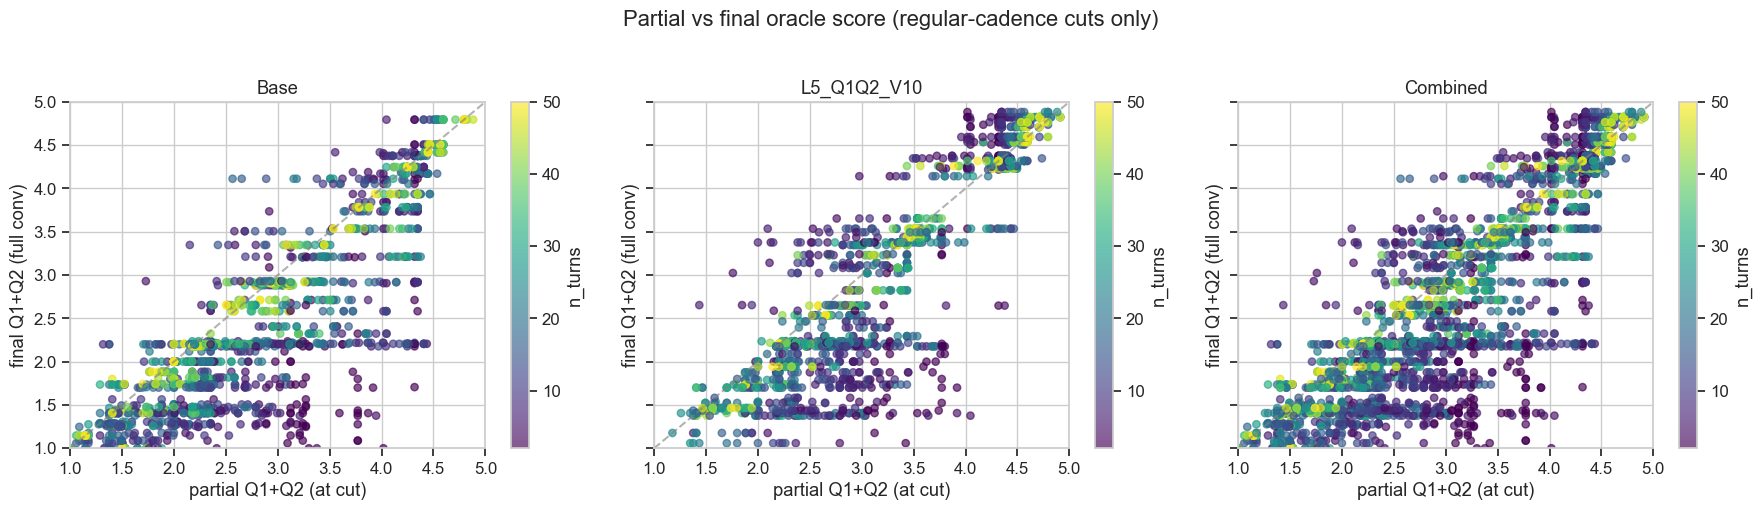

In [11]:
fig, axes = plt.subplots(1, len(MODELS), figsize=(6 * len(MODELS), 5), sharex=True, sharey=True)
if len(MODELS) == 1:
    axes = [axes]
for ax, model in zip(axes, MODELS):
    sub = partial_df[(partial_df["Model"] == model) & partial_df["on_cadence"]] \
            .dropna(subset=["final_Q1Q2_Mean"])
    sc = ax.scatter(sub["Q1Q2_Mean"], sub["final_Q1Q2_Mean"],
                    c=sub["n_turns"], cmap="viridis", alpha=0.65, s=28)
    ax.plot([1, 5], [1, 5], ls="--", color="gray", alpha=0.6)
    ax.set_xlim(1, 5); ax.set_ylim(1, 5)
    ax.set_title(model)
    ax.set_xlabel("partial Q1+Q2 (at cut)")
    ax.set_ylabel("final Q1+Q2 (full conv)")
    plt.colorbar(sc, ax=ax, label="n_turns")
plt.suptitle("Partial vs final oracle score (regular-cadence cuts only)", y=1.02)
plt.tight_layout()
plt.show()


## 10. Discussion & open questions

**What the data shows.**

1. The partial-conv reward is a noisy proxy for the full-conv eval *especially at the short cuts that dominate PTO/GRPO_Exp3 training data*. Pairwise rank agreement is **0.66 / 0.73 at `n_turns=2`** (Base / L5_V10) — well above chance but well below "trustworthy preference signal" territory. The per-cut |Δ| view (§6) tells the same story from the magnitude side: short cuts sit well above the noise floor.
2. Agreement increases monotonically with cut length, clearing **0.8 around `n_turns ≈ 10`** and **0.9 around `n_turns ≈ 30`**.
3. Oracle reproducibility noise (~0.07–0.10 mean |Δ|) is small relative to the partial-vs-final discrepancy, so the low agreement at short cuts is **structural, not measurement noise**.
4. L5_V10 has *slightly* tighter partial↔final alignment than Base at every cut length. Small but consistent shift — interpretation is open (§B below).

**Why this matters for the thesis.**

PTO and GRPO_Exp3 are trained on a reward where a non-trivial share of cuts have rank-agreement < 0.80 with the rubric we evaluate on. This is not random label noise — it's a *systematic short-conversation bias*. Short cuts can't observe whether the therapist actually delivered on Q1/Q2 by the end of the session, so the oracle scores them on something closer to "did the opening exchange look promising?". Optimising that proxy pushes the model toward openings that look promising regardless of follow-through.

**Open questions for supervisors.**

A. **Should we re-weight or filter training cuts by length?** E.g., drop cuts with `n_turns < 10`, or down-weight them in the loss. Trade-off: less data, possibly cleaner signal. Cheapest test: re-train one PTO run with `MIN_TURNS ≥ 10` and compare against the current run.

B. **Why does L5_V10's partial reward track its final eval more tightly than Base's does?** Two non-exclusive readings:
   - *Behavioural legibility:* training made the model's interventions recognisable to the oracle earlier, so partial-cut scores stabilise sooner. (Benign.)
   - *Look-good-early bias:* L5_V10 learned to produce openings that score well in isolation. (Concerning — exactly the failure mode the proxy gap would induce.)
   Distinguishing them probably needs a *within-conversation* analysis: does L5_V10 show smaller score variance across cuts of the same conversation than Base does?

C. **Is "pooled agreement ≈ 0.85" good enough?** DPO/PTO literature treats noisy preference labels as tolerable. But noise here is non-uniform and correlated with cut length — a feature the model can exploit.

D. **Should the oracle for partial cuts be a different prompt?** Asking gpt-4o-mini "rate this *opening* on Q1/Q2" might calibrate it to score what the cut can actually display, rather than implicitly scoring it as if it were a complete session.
